In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load the Raw Data (with encoding fix)
# ---------------------------------------------------------
try:
    df = pd.read_csv('data.csv', delimiter=';', encoding='ISO-8859-1')
except UnicodeDecodeError:
    df = pd.read_csv('data.csv', delimiter=';', encoding='cp1254')

In [158]:
# Check the data structure
print(f"Dataset Dimensions: {df.shape[0]} Rows, {df.shape[1]} Columns")

print("\n--- Data Preview ---")
display(df.head()) 

print("\n--- Data Info & Types ---")
df.info()

Dataset Dimensions: 1267 Rows, 24 Columns

--- Data Preview ---


,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1



--- Data Info & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Group                     1267 non-null   int64 
 1   Sex                       1267 non-null   int64 
 2   Age                       1267 non-null   int64 
 3   Patients number per hour  1267 non-null   int64 
 4   Arrival mode              1267 non-null   int64 
 5   Injury                    1267 non-null   int64 
 6   Chief_complain            1267 non-null   object
 7   Mental                    1267 non-null   int64 
 8   Pain                      1267 non-null   int64 
 9   NRS_pain                  1267 non-null   object
 10  SBP                       1267 non-null   object
 11  DBP                       1267 non-null   object
 12  HR                        1267 non-null   object
 13  RR                        1267 non-null   object
 1

In [159]:
# List of columns that are vital signs (should be numeric)
vital_cols = ['SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'NRS_pain']

print("--- Inspecting Dirty Values in Vital Signs ---")

for col in vital_cols:
    # 1. Try to force convert the column to numbers
    # 'errors="coerce"' turns any text (like '??', 'High') into NaN (missing)
    numeric_version = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Find rows where the ORIGINAL value was NOT null, but the CONVERSION became null
    # This isolates the "garbage" text specifically
    bad_rows = df[df[col].notna() & numeric_version.isna()]
    
    unique_errors = bad_rows[col].unique()
    
    if len(unique_errors) > 0:
        print(f"\nColumn '{col}' contains {len(unique_errors)} types of non-numeric errors:")
        print(unique_errors)

--- Inspecting Dirty Values in Vital Signs ---

Column 'SBP' contains 1 types of non-numeric errors:
['??']

Column 'DBP' contains 1 types of non-numeric errors:
['??']

Column 'HR' contains 1 types of non-numeric errors:
['??']

Column 'RR' contains 1 types of non-numeric errors:
['??']

Column 'BT' contains 1 types of non-numeric errors:
['??']

Column 'Saturation' contains 1 types of non-numeric errors:
['??']

Column 'NRS_pain' contains 1 types of non-numeric errors:
['#BOÞ!']


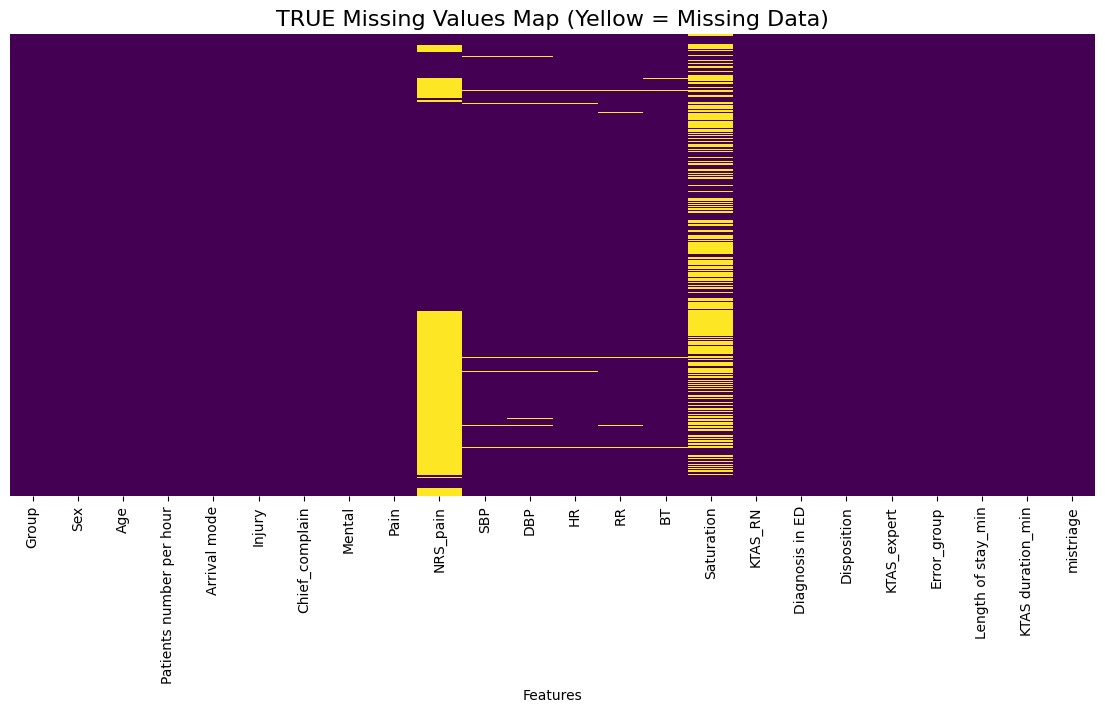


--- Missing Data Percentage ---
Saturation         55.011839
NRS_pain           43.883189
DBP                 2.288871
SBP                 1.973165
RR                  1.736385
HR                  1.578532
BT                  1.420679
Diagnosis in ED     0.157853
dtype: float64


In [160]:
# Create a temporary copy for visualization ONLY
df_viz = df.copy()

# Force convert vital columns to numeric (Errors become NaN)
# This reveals the "Hidden" missing values
cols_to_convert = ['Age', 'Patients number per hour', 'SBP', 'DBP', 'HR', 'RR', 'BT', 
                   'Saturation', 'NRS_pain', 'Pain', 'Mental', 'Arrival mode', 'Injury']

for col in cols_to_convert:
    df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')

# Now plot the Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(df_viz.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('TRUE Missing Values Map (Yellow = Missing Data)', fontsize=16)
plt.xlabel('Features')
plt.show()

# Print exact percentage of missing data
print("\n--- Missing Data Percentage ---")
missing_percent = df_viz.isnull().mean() * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

In [161]:
from sklearn.impute import SimpleImputer
# ---------------------------------------------------------
# 2. Define Column Types (Based on your Metadata)
# ---------------------------------------------------------
numeric_cols = ['Age', 'Patients number per hour', 'SBP', 'DBP', 
                'HR', 'RR', 'BT', 'Saturation', 'NRS_pain', 
                'Length of stay_min', 'KTAS duration_min']

categorical_cols = ['Group', 'Sex', 'Arrival mode', 'Injury', 'Mental', 
                    'Pain', 'Disposition', 'KTAS_RN', 'KTAS_expert']

# ---------------------------------------------------------
# 3. Clean and Impute
# ---------------------------------------------------------

# A. Fix Commas and Force Numeric Types
for col in numeric_cols:
    if col in df.columns:
        # If valid column is text, replace comma with dot
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        # Convert to number (errors become NaN)
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in categorical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# B. Smart Logic for Pain (Manual Fill - NO inplace=True)
if 'Pain' in df.columns and 'NRS_pain' in df.columns:
    # If Pain is 0 (No), force NRS to 0
    mask_no_pain = df['Pain'] == 0
    df.loc[mask_no_pain, 'NRS_pain'] = df.loc[mask_no_pain, 'NRS_pain'].fillna(0)

# C. Flag Missing Saturation
if 'Saturation' in df.columns:
    df['Saturation_Measured'] = df['Saturation'].notnull().astype(int)

# D. Impute True Numbers (Median)
num_imputer = SimpleImputer(strategy='median')
existing_num = [c for c in numeric_cols if c in df.columns]
# Only impute columns that aren't 100% empty
existing_num = [c for c in existing_num if df[c].notnull().sum() > 0]
if existing_num:
    df[existing_num] = num_imputer.fit_transform(df[existing_num])

# E. Impute Categories (Mode/Most Frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
existing_cat = [c for c in categorical_cols if c in df.columns]
if existing_cat:
    df[existing_cat] = cat_imputer.fit_transform(df[existing_cat])

df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage,Saturation_Measured
0,2,2,71.0,3.0,3,2,right ocular pain,1,1,2.0,...,100.0,2,Corneal abrasion,1,4,2,86.0,5.00,1,1
1,1,1,56.0,12.0,3,2,right forearm burn,1,1,2.0,...,98.0,4,"Burn of hand, firts degree dorsum",1,5,4,64.0,3.95,1,0
2,2,1,68.0,8.0,2,2,"arm pain, Lt",1,1,2.0,...,98.0,4,"Fracture of surgical neck of humerus, closed",2,5,4,862.0,1.00,1,1
3,1,2,71.0,8.0,1,1,ascites tapping,1,1,3.0,...,98.0,4,Alcoholic liver cirrhosis with ascites,1,5,6,108.0,9.83,1,0
4,1,2,58.0,4.0,3,1,"distension, abd",1,1,3.0,...,98.0,4,Ascites,1,5,8,109.0,6.60,1,0


In [162]:
# Save the comma-separated version
df.to_csv('data_converted.csv', index=False)

print("File 'data_converted.csv' has been saved successfully.")

File 'data_converted.csv' has been saved successfully.


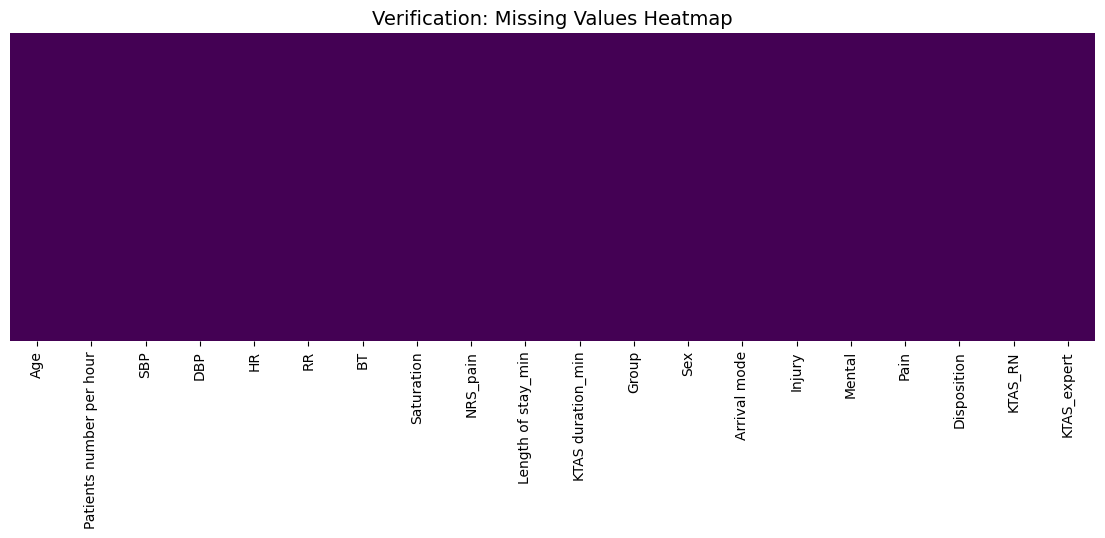

C:\Users\lcm03\AppData\Local\Temp\ipykernel_2412\4253839866.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Arrival mode'], ax=ax[3], palette='pastel')


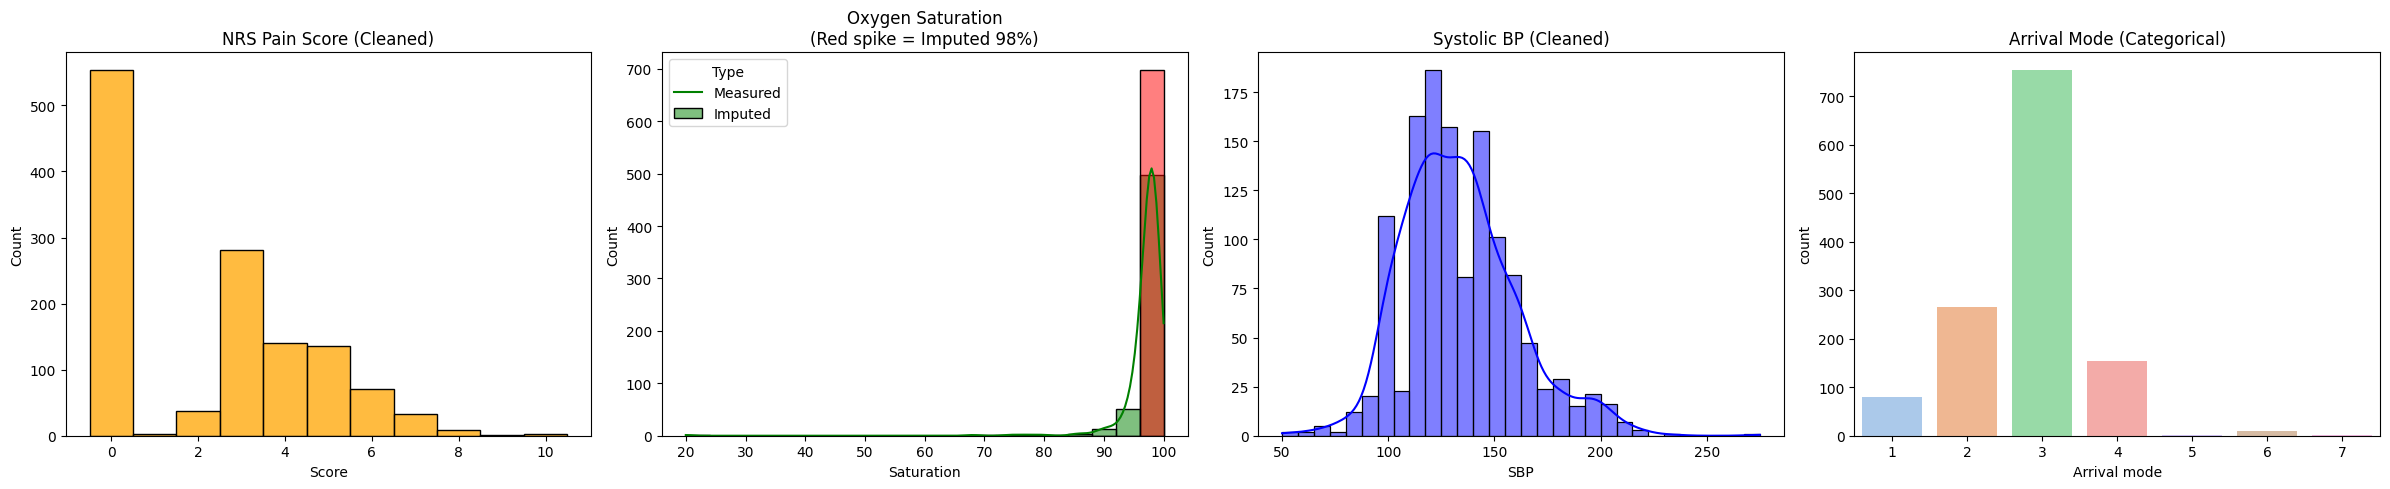

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Step 2: Verification (Enhanced)
# ---------------------------------------------------------

# 1. Heatmap Check (Using the correct column lists)
# We combine the lists we made earlier to check everything at once
all_cleaned_cols = numeric_cols + categorical_cols

plt.figure(figsize=(14, 4))
sns.heatmap(df[all_cleaned_cols].isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Verification: Missing Values Heatmap', fontsize=14)
plt.show()

# 2. Check Distributions (With Imputation Insights)
fig, ax = plt.subplots(1, 4, figsize=(24, 5)) # Added a 4th plot for Categories

# A. Pain Score (Discrete=True makes it look like a bar chart for 0-10)
sns.histplot(df['NRS_pain'], bins=11, kde=False, ax=ax[0], color='orange', discrete=True)
ax[0].set_title('NRS Pain Score (Cleaned)')
ax[0].set_xlabel('Score')

# B. Oxygen Saturation (The "Truth" Plot)
# hue='Saturation_Measured' shows Real (1) vs Imputed (0) in different colors!
if 'Saturation_Measured' in df.columns:
    sns.histplot(data=df, x='Saturation', hue='Saturation_Measured', 
                 bins=20, kde=True, ax=ax[1], palette=['red', 'green'])
    ax[1].legend(title='Type', labels=['Measured', 'Imputed'])
else:
    sns.histplot(df['Saturation'], bins=20, kde=True, ax=ax[1], color='green')
ax[1].set_title('Oxygen Saturation\n(Red spike = Imputed 98%)')

# C. Systolic BP (Continuous Data)
sns.histplot(df['SBP'], bins=30, kde=True, ax=ax[2], color='blue')
ax[2].set_title('Systolic BP (Cleaned)')

# D. Categorical Check (Arrival Mode)
# Verifying we have nice integers (1, 2, 3) and not "1.5"
sns.countplot(x=df['Arrival mode'], ax=ax[3], palette='pastel')
ax[3].set_title('Arrival Mode (Categorical)')

plt.tight_layout()
plt.show()

In [164]:
# --- DEFINE THE LIST FIRST ---
vitals_to_check = ['SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']

print("1. Missing values BEFORE outlier cleaning:")
# Now Python knows what 'vitals_to_check' is
print(df[vitals_to_check].isnull().sum())
print("-" * 30)

1. Missing values BEFORE outlier cleaning:
SBP           0
DBP           0
HR            0
RR            0
BT            0
Saturation    0
dtype: int64
------------------------------


Original Dataset Shape: (1267, 25)
[BT] Invalidated 0 values outside 25-45C
------------------------------
Cleaning Complete. Values set to NaN where impossible.


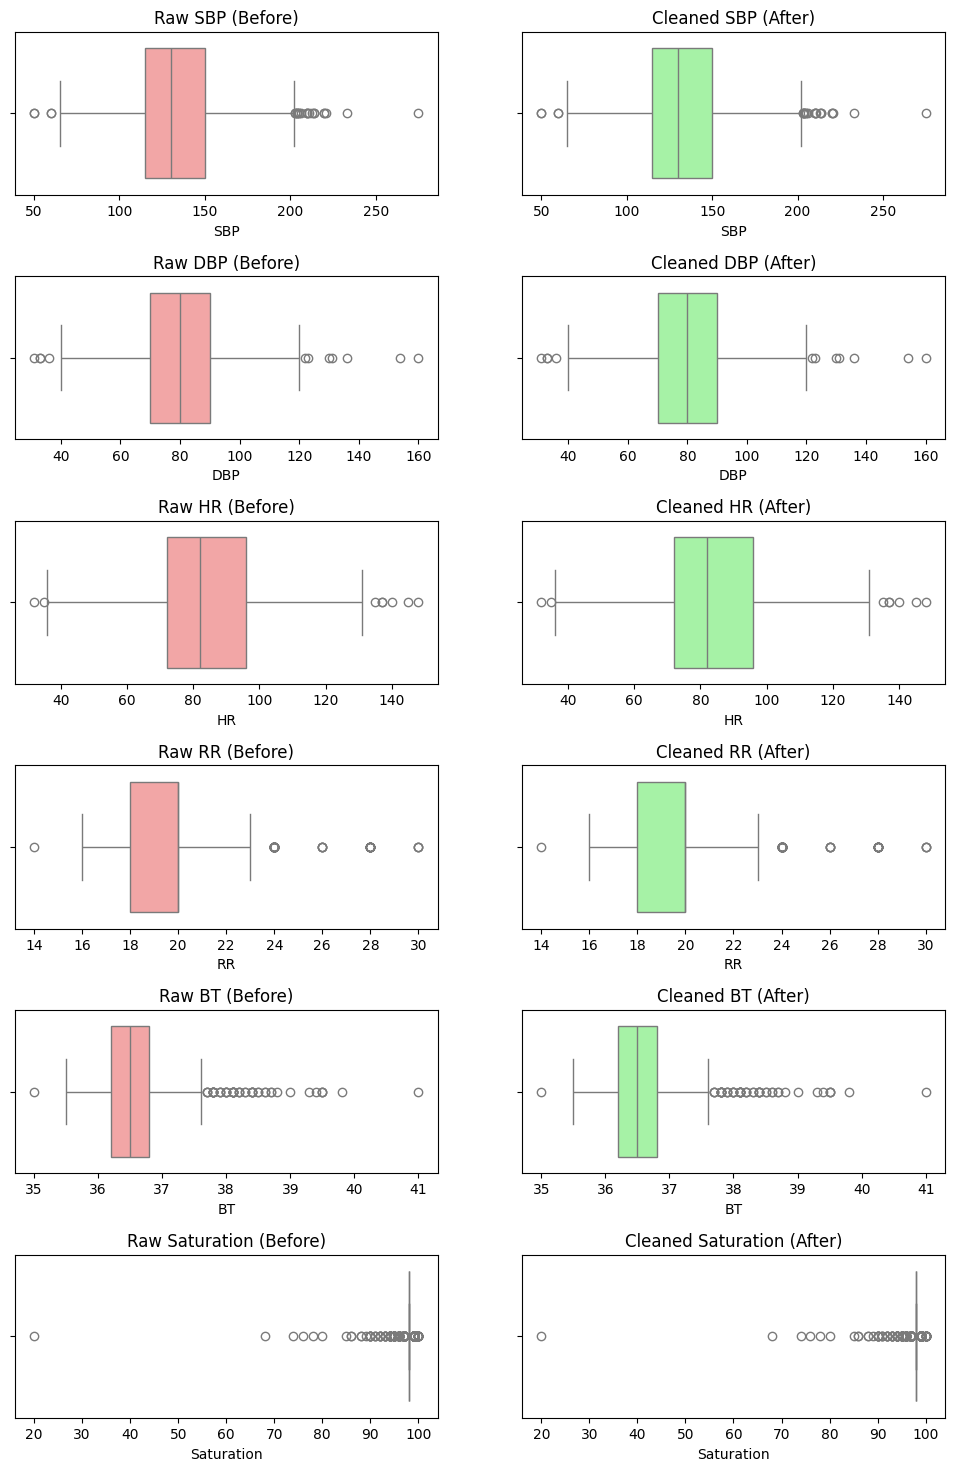

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # Needed for NaN

# ---------------------------------------------------------
# Step 2.5: Outlier Detection & Handling (Enhanced)
# ---------------------------------------------------------

# Define list of vitals
vitals_to_check = ['SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']

# --- 1. CONFIGURATION: Define Domain Limits ---
limits = {
    'HR':  (0, 300),      # Heart Rate
    'SBP': (0, 300),      # Systolic BP
    'DBP': (0, 200),      # Diastolic BP
    'RR':  (0, 60),       # Respiratory Rate
    'BT':  (25, 45),      # Body Temp (Celsius)
    # Saturation is handled separately due to the "clipping" rule
}

print(f"Original Dataset Shape: {df.shape}")

# --- 2. VISUALIZATION: Before & After Setup ---
fig, axes = plt.subplots(len(vitals_to_check), 2, figsize=(12, 18))
plt.subplots_adjust(hspace=0.5)

# --- 3. LOGIC LOOP ---
for i, col in enumerate(vitals_to_check):
    
    # --- A. Visualize Raw Data (Left Column) ---
    sns.boxplot(x=df[col], ax=axes[i, 0], color='#ff9999') # Red for 'Raw'
    axes[i, 0].set_title(f'Raw {col} (Before)')

    # --- B. Apply Cleaning Logic ---
    
    # Rule 1: Saturation Capping
    if col == 'Saturation':
        # Report
        over_100 = df[df[col] > 100].shape[0]
        if over_100 > 0:
            print(f"[{col}] Fixed {over_100} values > 100% (Clipped to 100)")
            df[col] = df[col].clip(upper=100)
        
        # Also remove impossible lows (e.g., 0 usually means sensor off)
        # Using np.nan preserves the row but marks value as missing
        mask_low = df[col] <= 0
        df.loc[mask_low, col] = np.nan 

    # Rule 2: Body Temperature Decimal Fix
    elif col == 'BT':
        # Detect missing decimals (e.g., 365 -> 36.5)
        mask_decimal = df[col] > 100
        count_fix = mask_decimal.sum()
        if count_fix > 0:
            print(f"[{col}] Fixed {count_fix} decimal errors (e.g., 365 -> 36.5)")
            df.loc[mask_decimal, col] = df.loc[mask_decimal, col] / 10
            
        # Standard Bounds Check
        lower, upper = limits[col]
        mask_outlier = (df[col] < lower) | (df[col] > upper)
        print(f"[{col}] Invalidated {mask_outlier.sum()} values outside {lower}-{upper}C")
        df.loc[mask_outlier, col] = np.nan

    # Rule 3: General Bounds for HR, BP, RR
    elif col in limits:
        lower, upper = limits[col]
        # Identify bad values
        mask_outlier = (df[col] <= lower) | (df[col] >= upper)
        
        if mask_outlier.sum() > 0:
            print(f"[{col}] Invalidated {mask_outlier.sum()} values (Limit: {lower}-{upper})")
            # Set specific cell to NaN, don't drop the row
            df.loc[mask_outlier, col] = np.nan

    # --- C. Visualize Cleaned Data (Right Column) ---
    sns.boxplot(x=df[col], ax=axes[i, 1], color='#99ff99') # Green for 'Clean'
    axes[i, 1].set_title(f'Cleaned {col} (After)')

# --- 4. Final Cleanup ---
# Optional: Drop rows only if ALL vitals are now NaN (empty rows)
# df.dropna(subset=vitals_to_check, how='all', inplace=True)

print("-" * 30)
print(f"Cleaning Complete. Values set to NaN where impossible.")
plt.show()

In [166]:
print("2. Missing values AFTER outlier cleaning:")
print(df[vitals_to_check].isnull().sum())

2. Missing values AFTER outlier cleaning:
SBP           0
DBP           0
HR            0
RR            0
BT            0
Saturation    0
dtype: int64


In [167]:
counts = df['Chief_complain'].value_counts()

# 2. Filter for items appearing less than the threshold
threshold = 1000 
rare_items = counts[counts < threshold]

# --- NEW: Calculate Total Affected Rows ---
total_rare_cases = rare_items.sum()
# ------------------------------------------

print(f"⚠️ FOUND {len(rare_items)} RARE CATEGORIES (Frequency < {threshold})")
print(f"📉 Total Patients Affected: {total_rare_cases}")
print("-" * 40)

# 3. Print them so you can decide if they are "Garbage" or "Gold"
for complaint, count in rare_items.items():
    print(f"{complaint} (Count: {count})")

⚠️ FOUND 417 RARE CATEGORIES (Frequency < 1000)
📉 Total Patients Affected: 1267
----------------------------------------
abd pain (Count: 72)
dyspnea (Count: 60)
dizziness (Count: 59)
fever (Count: 45)
ant. chest pain (Count: 44)
Open Wound (Count: 31)
headache (Count: 30)
epigastric pain (Count: 22)
mental change (Count: 22)
general weakness (Count: 21)
vomiting (Count: 16)
pain, chest (Count: 16)
hematemesis (Count: 14)
Abd. pain (Count: 12)
Left chest pain (Count: 12)
Lt flank pain (Count: 11)
syncope (Count: 10)
abdomen pain (Count: 10)
dysarthria (Count: 10)
Vaginal Bleeding (Count: 9)
palpitation (Count: 9)
facial injury (Count: 9)
Urticarial rash (Count: 8)
melena (Count: 8)
RUQ pain (Count: 8)
pain, abdominal (Count: 8)
H-Headache (Count: 7)
epistaxis (Count: 7)
post seizure (Count: 7)
pain, low back (Count: 7)
hematochezia (Count: 7)
Rt. flank pain (Count: 7)
HA (Count: 6)
ocular pain, Lt. (Count: 6)
ocular pain, Rt. (Count: 6)
anxiety (Count: 6)
diarrhea (Count: 6)
Ankle Inju

In [168]:
import pandas as pd
# 1. Update the function with the "Missed" categories you found
def clean_chief_complaint_final(text):
    text = str(text).lower().strip()
    # --- 1. FIX: The "Other" buckets ---
    # If the text is literally just "other" or "others", capitalize it standardly
    if text in ['other', 'others']:
        return 'Other'
    # --- 2. SPECIFIC OVERRIDES (Based on your output) ---
    if text in ['ha', 'h-headache', 'headache']: return 'Headache'
    if 'foreign body' in text: return 'Trauma/Injury'
    # --- 3. NEW GROUPS (From your findings) ---
    # Eye
    if any(x in text for x in ['ocular', 'visual', 'eye', 'vision', 'blurred']):
        return 'Eye Problem'
    # Urinary
    if any(x in text for x in ['urinary', 'dysuria', 'voiding', 'urine', 'bladder']):
        return 'Urinary Issue'
    # Psychiatric
    if any(x in text for x in ['anxiety', 'suicidal', 'depression', 'mood', 'panic', 'psych']):
        return 'Psychiatric'
    # Musculoskeletal (Leg pain, Myalgia)
    if any(x in text for x in ['leg', 'muscle', 'myalgia', 'arm', 'limb', 'joint']):
        return 'Musculoskeletal Pain'
    # --- 4. EXISTING GROUPS (Same as before) ---
    if any(x in text for x in ['abd', 'epigastric', 'flank', 'stomach', 'rlq', 'llq', 'ruq', 'luq', 'periumbilical']): return 'Abdominal Pain'
    if any(x in text for x in ['chest', 'precordial']): return 'Chest Pain'
    if 'head' in text or 'migraine' in text: return 'Headache'
    if any(x in text for x in ['back', 'lbp', 'lumbar', 'coccyx']): return 'Back Pain'
    if any(x in text for x in ['dizz', 'vertigo', 'spinning']): return 'Dizziness'
    if any(x in text for x in ['weakness', 'motor', 'hemi', 'paralysis', 'dysarthria', 'stroke', 'slurred']): return 'Neurological Deficit'
    if any(x in text for x in ['mental', 'confusion', 'altered', 'agitation', 'drowsy', 'conscious']): return 'Altered Mental Status'
    if any(x in text for x in ['syncope', 'faint']): return 'Syncope'
    if any(x in text for x in ['seizure', 'convulsion', 'fit']): return 'Seizure'
    if any(x in text for x in ['laceration', 'wound', 'injury', 'fracture', 'burn', 'trauma', 'cut', 'abrasion', 'bite', 'sting', 'fall', 'slip']): return 'Trauma/Injury'
    if any(x in text for x in ['vomit', 'nausea', 'emesis']): return 'Nausea/Vomiting'
    if any(x in text for x in ['diarrhea', 'stool', 'melena', 'hematochezia', 'constipation']): return 'Diarrhea/GI Issue'
    if any(x in text for x in ['dyspnea', 'breath', 'air', 'sob', 'cough', 'throat']): return 'Respiratory/Dyspnea'
    if any(x in text for x in ['rash', 'urticaria', 'itch', 'swelling', 'edema', 'hives', 'allergy']): return 'Skin/Allergy'
    if 'fever' in text: return 'Fever'
    if 'palpitation' in text: return 'Palpitation'
    if any(x in text for x in ['bleeding', 'hemoptysis', 'hematemesis', 'epistaxis', 'blood']): return 'Bleeding (General)'
    # If no match found, return 'Other' directly to clean up the tail
    return 'Other'
# A. SEX: Raw (1=Female, 2=Male) -> Target (0=Female, 1=Male)
# We simply subtract 1.
df['Sex'] = df['Sex'] - 1
# B. INJURY: Raw (1=No, 2=Yes) -> Target (0=No, 1=Yes)
# We simply subtract 1.
df['Injury'] = df['Injury'] - 1
# C. ARRIVAL MODE: Grouping
# Raw: 1=Walk, 2=Pub Amb, 3=Car, 4=Priv Amb
# Goal: 1=Ambulance, 2=Walk/Car, 3=Other
def clean_arrival_numeric(val):
    if val in [2, 4]: return 1    # Ambulance (Public or Private)
    elif val in [1, 3]: return 2  # Walk / Private Car
    else: return 3                # Other
df['Arrival mode'] = df['Arrival mode'].apply(clean_arrival_numeric)
# 2. Apply Final Cleaning
print("Applying Final Polish...")
df['Chief_complain_Cleaned'] = df['Chief_complain'].apply(clean_chief_complaint_final)
# 3. Final Check and Total Count
counts = df['Chief_complain_Cleaned'].value_counts()
total_patients = counts.sum()
print("\n--- FINAL CLEANED DISTRIBUTION ---")
print(counts)
print("-" * 30)
print(f"📊 TOTAL PATIENTS ACCOUNTED FOR: {total_patients}")

Applying Final Polish...

--- FINAL CLEANED DISTRIBUTION ---
Chief_complain_Cleaned
Abdominal Pain           225
Other                    185
Chest Pain               102
Trauma/Injury             95
Respiratory/Dyspnea       76
Dizziness                 69
Neurological Deficit      67
Headache                  56
Fever                     49
Musculoskeletal Pain      49
Eye Problem               45
Altered Mental Status     37
Nausea/Vomiting           36
Bleeding (General)        35
Skin/Allergy              33
Diarrhea/GI Issue         27
Back Pain                 18
Seizure                   15
Urinary Issue             15
Psychiatric               13
Syncope                   11
Palpitation                9
Name: count, dtype: int64
------------------------------
📊 TOTAL PATIENTS ACCOUNTED FOR: 1267


In [169]:
# Check unique values to see if they are Text or Numbers
cols_to_check = ['Sex', 'Arrival mode', 'Injury', 'Mental', 'Pain']

print("--- Data Type Inspection ---")
for col in cols_to_check:
    if col in df.columns:
        unique_vals = df[col].unique()
        print(f"[{col}] Data Type: {df[col].dtype}")
        print(f"   First 5 unique values: {unique_vals[:5]}")
        print("-" * 30)

--- Data Type Inspection ---
[Sex] Data Type: int64
   First 5 unique values: [1 0]
------------------------------
[Arrival mode] Data Type: int64
   First 5 unique values: [2 1 3]
------------------------------
[Injury] Data Type: int64
   First 5 unique values: [1 0]
------------------------------
[Mental] Data Type: int64
   First 5 unique values: [1 2 3 4]
------------------------------
[Pain] Data Type: int64
   First 5 unique values: [1 0]
------------------------------


In [170]:
# ---------------------------------------------------------
# Step 3: Feature Engineering, Splitting & Balancing (Enhanced)
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd
# 1. Feature Selection
# Use 'Chief_complain_Cleaned' instead of the raw version
feature_cols = ['Sex', 'Age', 'Arrival mode', 'Injury', 'Chief_complain_Cleaned',
                'Mental', 'Pain', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']
target_col = 'KTAS_expert'
X = df[feature_cols].copy()
y = df[target_col].copy()
# 2. Encoding Categorical Data (Text -> Numbers)
# Models cannot read "Chest Pain" or "Male". We use One-Hot Encoding.
# This creates columns like "Chief_complain_Chest Pain" [0 or 1]
print("--- Encoding Categorical Features ---")
X_encoded = pd.get_dummies(X, columns=['Chief_complain_Cleaned'], drop_first=True)
print(f"Shape after Encoding: {X_encoded.shape}")
# 3. Train-Test Split (CRITICAL: Do this BEFORE SMOTE)
# We hide 20% of real data for testing. The model NEVER sees this during training.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training Set Size: {X_train.shape[0]}")
print(f"Test Set Size: {X_test.shape[0]}")
# 4. Balancing with SMOTE (Oversampling)
# We only balance the TRAINING data. The Test data must remain natural/imbalanced.
print("\n--- Applying SMOTE (Balancing) ---")
print(f"Class distribution BEFORE SMOTE:\n{y_train.value_counts().sort_index()}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"Class distribution AFTER SMOTE:\n{y_train_balanced.value_counts().sort_index()}")
print("-" * 30)
print("✅ Ready for Model Training!")

--- Encoding Categorical Features ---
Shape after Encoding: (1267, 34)
Training Set Size: 1013
Test Set Size: 254

--- Applying SMOTE (Balancing) ---
Class distribution BEFORE SMOTE:
KTAS_expert
1     21
2    176
3    389
4    367
5     60
Name: count, dtype: int64
Class distribution AFTER SMOTE:
KTAS_expert
1    389
2    389
3    389
4    389
5    389
Name: count, dtype: int64
------------------------------
✅ Ready for Model Training!


In [171]:
# ---------------------------------------------------------
# Step 3.5: Save Data & Final Sanity Check
# ---------------------------------------------------------
# 1. SAVE to CSV (Optional but Recommended)
# We save the Balanced Train set (for training) and the Original Test set (for evaluating)
print("💾 Saving processed datasets to CSV...")
X_train_balanced.to_csv('X_train_final.csv', index=False)
y_train_balanced.to_csv('y_train_final.csv', index=False)
X_test.to_csv('X_test_final.csv', index=False)
y_test.to_csv('y_test_final.csv', index=False)
print("✅ Data saved successfully.")
# 2. FINAL SANITY CHECK (The "Pre-Flight" Inspection)
print("\n--- 🔍 Pre-Flight Check ---")
# Check A: Do we have any Missing Values left? (Must be 0)
missing_train = X_train_balanced.isnull().sum().sum()
missing_test = X_test.isnull().sum().sum()
print(f"Missing Values in Train: {missing_train}")
print(f"Missing Values in Test:  {missing_test}")
# Check B: Did One-Hot Encoding work?
# We check if we have the new columns
print("\nNew Columns Created (First 5):")
cols = [c for c in X_train_balanced.columns if 'Chief_complain' in c]
print(cols[:5])
# Check C: Visualizing the Balance
# You should see equal numbers for all classes now
print("\nFinal Training Class Distribution:")
print(y_train_balanced.value_counts().sort_index())
if missing_train == 0 and missing_test == 0:
    print("\n🚀 ALL SYSTEMS GO. Ready for Training.")
else:
    print("\n⚠️ STOP. You have missing values. Do not train yet.")

💾 Saving processed datasets to CSV...
✅ Data saved successfully.

--- 🔍 Pre-Flight Check ---
Missing Values in Train: 0
Missing Values in Test:  0

New Columns Created (First 5):
['Chief_complain_Cleaned_Altered Mental Status', 'Chief_complain_Cleaned_Back Pain', 'Chief_complain_Cleaned_Bleeding (General)', 'Chief_complain_Cleaned_Chest Pain', 'Chief_complain_Cleaned_Diarrhea/GI Issue']

Final Training Class Distribution:
KTAS_expert
1    389
2    389
3    389
4    389
5    389
Name: count, dtype: int64

🚀 ALL SYSTEMS GO. Ready for Training.


In [172]:
# Check the new column names created by One-Hot Encoding
print("--- New Features Created ---")
for col in X_encoded.columns:
    # Print only the columns related to complaints
    if 'Chief_complain' in col:
        print(col)

--- New Features Created ---
Chief_complain_Cleaned_Altered Mental Status
Chief_complain_Cleaned_Back Pain
Chief_complain_Cleaned_Bleeding (General)
Chief_complain_Cleaned_Chest Pain
Chief_complain_Cleaned_Diarrhea/GI Issue
Chief_complain_Cleaned_Dizziness
Chief_complain_Cleaned_Eye Problem
Chief_complain_Cleaned_Fever
Chief_complain_Cleaned_Headache
Chief_complain_Cleaned_Musculoskeletal Pain
Chief_complain_Cleaned_Nausea/Vomiting
Chief_complain_Cleaned_Neurological Deficit
Chief_complain_Cleaned_Other
Chief_complain_Cleaned_Palpitation
Chief_complain_Cleaned_Psychiatric
Chief_complain_Cleaned_Respiratory/Dyspnea
Chief_complain_Cleaned_Seizure
Chief_complain_Cleaned_Skin/Allergy
Chief_complain_Cleaned_Syncope
Chief_complain_Cleaned_Trauma/Injury
Chief_complain_Cleaned_Urinary Issue


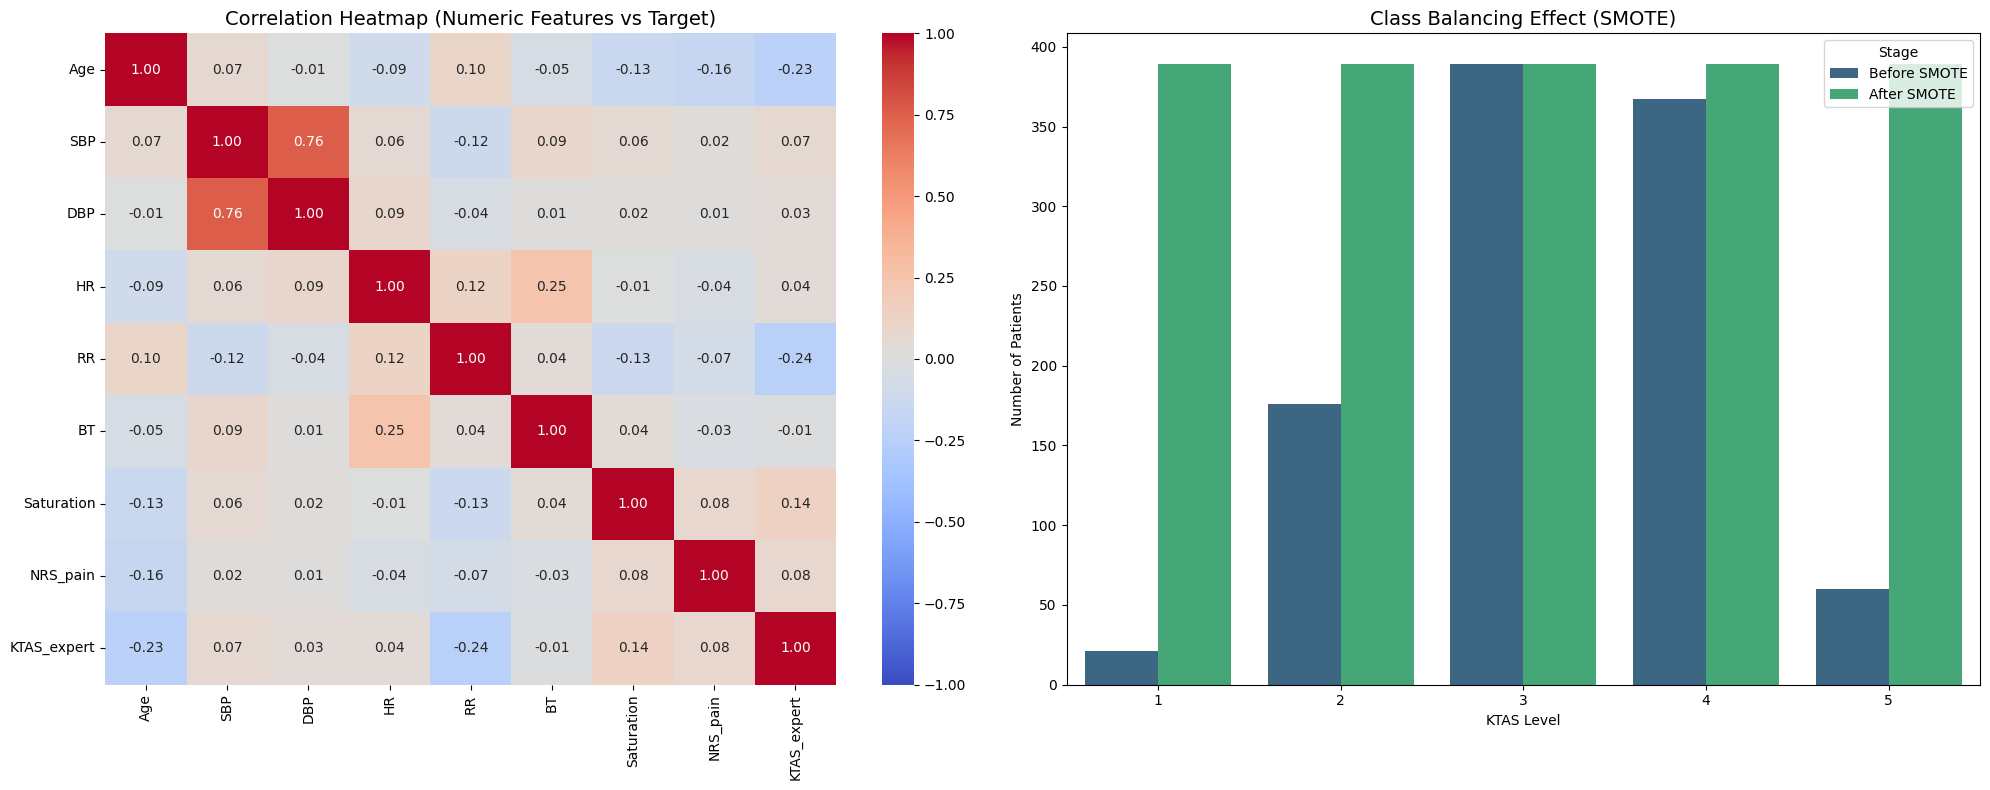

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Step 3.5: Pre-Model Visualization
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# --- PLOT 1: Correlation Matrix (Numeric Features Only) ---
# We focus on numeric cols to keep it readable
numeric_focus = ['Age', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'NRS_pain', 'KTAS_expert']
corr_data = df[numeric_focus].corr()

sns.heatmap(corr_data, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title('Correlation Heatmap (Numeric Features vs Target)', fontsize=14)

# --- PLOT 2: SMOTE Effect (Class Distribution) ---
# We create a temporary dataframe just for plotting
smote_plot_df = pd.DataFrame({
    'Stage': ['Before SMOTE'] * len(y_train) + ['After SMOTE'] * len(y_train_balanced),
    'KTAS Level': list(y_train) + list(y_train_balanced)
})

sns.countplot(data=smote_plot_df, x='KTAS Level', hue='Stage', ax=ax[1], palette='viridis')
ax[1].set_title('Class Balancing Effect (SMOTE)', fontsize=14)
ax[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

🔧 Adjusting labels to 0-4 range for compatibility...
   Original Labels: [1, 2, 3, 4, 5]
   New Labels:      [0, 1, 2, 3, 4]

🥊 STARTING HYPERPARAMETER TUNING...
------------------------------------------------------------
Model                     | Status         
------------------------------------------------------------


C:\Users\lcm03\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Logistic Regression       | Done! (Acc: 63.39%)
Random Forest             | Done! (Acc: 73.23%)


C:\Users\lcm03\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:58:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost                   | Done! (Acc: 73.62%)


C:\Users\lcm03\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\lcm03\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                  | Done! (Acc: 69.29%)
SVM (Support Vector)      | Done! (Acc: 69.69%)
KNN                       | Done! (Acc: 62.99%)
Decision Tree             | Done! (Acc: 56.69%)

🏆 FINAL CHAMPIONSHIP LEADERBOARD 🏆
                  Model  Test Accuracy  Test AUC
2               XGBoost       0.736220  0.894029
1         Random Forest       0.732283  0.883061
4  SVM (Support Vector)       0.696850  0.880577
3              LightGBM       0.692913  0.885450
0   Logistic Regression       0.633858  0.875063
5                   KNN       0.629921  0.854594
6         Decision Tree       0.566929  0.695144


C:\Users\lcm03\AppData\Local\Temp\ipykernel_2412\294914560.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test Accuracy', y='Model', data=results_df, palette='viridis')


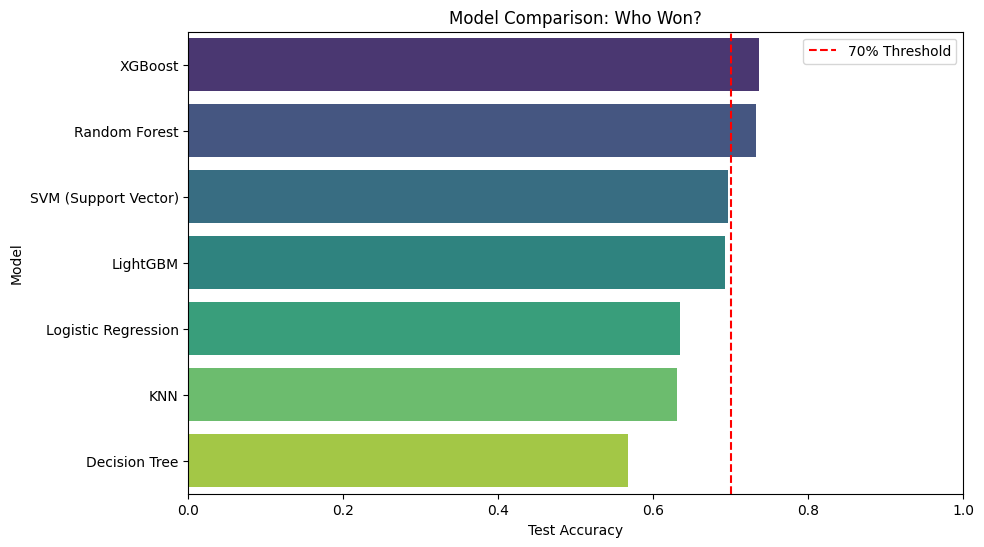

🥇 The Winner is: XGBoost
   Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 100}


In [174]:
# ---------------------------------------------------------
# Step 5: Advanced Multi-Model Training with Tuning 
# ---------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. FIX TARGET LABELS (Crucial for XGBoost/LGBM)
# We strictly map [1,2,3,4,5] -> [0,1,2,3,4]
print("🔧 Adjusting labels to 0-4 range for compatibility...")
y_train_tuned = y_train - 1
y_test_tuned = y_test - 1
print(f"   Original Labels: {sorted(y_train.unique())}")
print(f"   New Labels:      {sorted(y_train_tuned.unique())}")

# 2. Setup Cross-Validation
# 5-Folds means we train 5 times per setting to be sure of the result
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define Models & Grids
# We use X_train (Encoded but Unbalanced). The Pipeline handles SMOTE automatically.
models_config = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(solver='liblinear', random_state=42),
        'params': {'classifier__C': [1, 10], 'classifier__penalty': ['l2']}
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20, None]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        'params': {
            'classifier__learning_rate': [0.1],
            'classifier__max_depth': [6, 10],
            'classifier__n_estimators': [100, 200]
        }
    },
    {
        'name': 'LightGBM',
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'params': {
            'classifier__learning_rate': [0.1],
            'classifier__num_leaves': [31, 50],
            'classifier__n_estimators': [100]
        }
    },
    {
        'name': 'SVM (Support Vector)',
        'model': SVC(probability=True, random_state=42),
        'params': {'classifier__C': [1, 10], 'classifier__kernel': ['rbf']}
    },
    {
        'name': 'KNN',
        'model': KNeighborsClassifier(),
        'params': {'classifier__n_neighbors': [5, 9], 'classifier__weights': ['distance']}
    },
    {
        'name': 'Decision Tree',
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'classifier__max_depth': [10, 20]}
    }
]

# 4. TRAINING LOOP
results = []
best_estimators = {}

print("\n🥊 STARTING HYPERPARAMETER TUNING...")
print("-" * 60)
print(f"{'Model':<25} | {'Status':<15}")
print("-" * 60)

for config in models_config:
    model_name = config['name']
    print(f"{model_name:<25} | Tuning...", end='\r')
    
    # PIPELINE: Scale -> SMOTE -> Train
    # This prevents leakage because SMOTE happens ONLY on the training fold
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()), 
        ('balancing', SMOTE(random_state=42)),
        ('classifier', config['model'])
    ])
    
    # Grid Search (Finding the best settings)
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1 # Uses all CPU cores
    )
    
    # Train on X_train (Encoded, Unbalanced) and y_train_tuned (0-4)
    grid.fit(X_train, y_train_tuned)
    
    # Get Best Version
    best_model = grid.best_estimator_
    
    # Predict on Test Set
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)
    
    # Metrics
    acc = accuracy_score(y_test_tuned, y_pred)
    try:
        auc = roc_auc_score(y_test_tuned, y_prob, multi_class='ovr')
    except:
        auc = 0 # Fallback if AUC fails
    
    # Save Results
    results.append({
        'Model': model_name,
        'Test Accuracy': acc,
        'Test AUC': auc,
        'Best Params': grid.best_params_
    })
    
    best_estimators[model_name] = best_model
    print(f"{model_name:<25} | Done! (Acc: {acc:.2%})")

# 5. VISUALIZATION
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)

print("\n🏆 FINAL CHAMPIONSHIP LEADERBOARD 🏆")
print(results_df[['Model', 'Test Accuracy', 'Test AUC']])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Test Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: Who Won?')
plt.axvline(0.70, color='r', linestyle='--', label='70% Threshold')
plt.xlim(0, 1.0)
plt.legend()
plt.show()

# 6. EXPORT THE WINNER
winner_name = results_df.iloc[0]['Model']
winner_model = best_estimators[winner_name]
print(f"🥇 The Winner is: {winner_name}")
print(f"   Best Parameters: {results_df.iloc[0]['Best Params']}")

🧹 Preparing Pure Data (No Shock Index, No Extra Features)...
⚖️ Applying SMOTE to the original dataset...
   Original Training Shape: (1013, 34)
   Balanced Training Shape: (1945, 34)

🤝 Building the Voting Ensemble Model...


C:\Users\lcm03\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:58:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Ensemble Training Complete.

🏆 PURE ENSEMBLE ACCURACY: 73.62%
🚀 IMPROVEMENT! Removing the extra features helped.


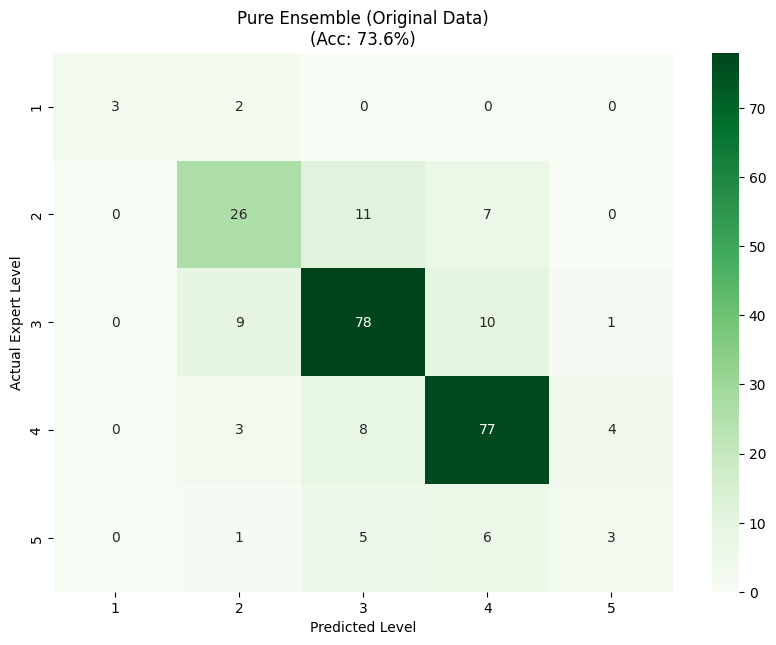

In [175]:
# ---------------------------------------------------------
# Step 6 (Revised): The "Pure" Ensemble (No Extra Features)
# ---------------------------------------------------------
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# 1. PREPARE THE DATA
print("🧹 Preparing Pure Data (No Shock Index, No Extra Features)...")
# We go back to the original X_train / X_test from Step 3.
# These variables contain only the raw vitals (SBP, DBP, HR, etc.) + Encoded Text.

# 2. BALANCE THE DATA (Crucial for Ensemble)
# Even though we aren't creating new features, we MUST balance the original X_train
# before feeding it to the Ensemble (otherwise it ignores Level 1 patients).
print("⚖️ Applying SMOTE to the original dataset...")
smote_pure = SMOTE(random_state=42)
X_train_pure_bal, y_train_pure_bal = smote_pure.fit_resample(X_train, y_train_tuned)

print(f"   Original Training Shape: {X_train.shape}")
print(f"   Balanced Training Shape: {X_train_pure_bal.shape}")

# 3. DEFINE THE ENSEMBLE
print("\n🤝 Building the Voting Ensemble Model...")

clf1 = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
clf2 = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', learning_rate=0.1, max_depth=6, random_state=42)
clf3 = LGBMClassifier(random_state=42, verbose=-1, learning_rate=0.1, num_leaves=31)

# Soft Voting = Average Probabilities
ensemble_pure = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2), ('lgbm', clf3)],
    voting='soft'
)

# 4. TRAIN ON PURE BALANCED DATA
ensemble_pure.fit(X_train_pure_bal, y_train_pure_bal)
print("✅ Ensemble Training Complete.")

# 5. EVALUATE (On Original Test Set)
y_pred_pure = ensemble_pure.predict(X_test)
acc_pure = accuracy_score(y_test_tuned, y_pred_pure)

print(f"\n🏆 PURE ENSEMBLE ACCURACY: {acc_pure:.2%}")

# Compare with previous results
if acc_pure > 0.7087:
    print("🚀 IMPROVEMENT! Removing the extra features helped.")
else:
    print("📉 Score is lower or same. The features weren't the problem.")

# 6. CONFUSION MATRIX
y_test_real = y_test_tuned + 1
y_pred_real = y_pred_pure + 1

cm = confusion_matrix(y_test_real, y_pred_real)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])
plt.xlabel('Predicted Level')
plt.ylabel('Actual Expert Level')
plt.title(f'Pure Ensemble (Original Data)\n(Acc: {acc_pure:.1%})')
plt.show()

🏆 Finalizing the Single XGBoost Champion...


C:\Users\lcm03\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:58:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Final Model Trained & Ready.

📊 FINAL TEST ACCURACY: 71.65%

--- Detailed Classification Report ---
                 precision    recall  f1-score   support

Level 1 (Resus)       1.00      0.80      0.89         5
Level 2 (Emerg)       0.63      0.61      0.62        44
  Level 3 (Urg)       0.74      0.77      0.75        98
 Level 4 (Less)       0.78      0.79      0.78        92
  Level 5 (Non)       0.27      0.20      0.23        15

       accuracy                           0.72       254
      macro avg       0.68      0.63      0.66       254
   weighted avg       0.71      0.72      0.71       254



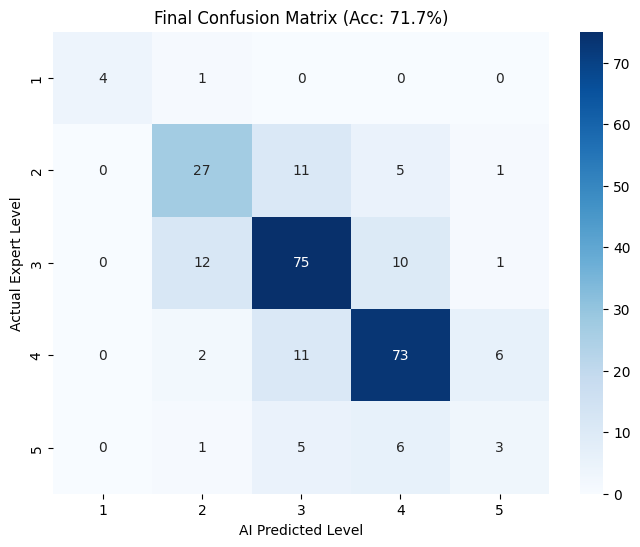


💾 Model Saved: 'ktas_final_champion.pkl'


In [176]:
# ---------------------------------------------------------
# Step 7a: Final Champion Training & Quantitative Evaluation
# ---------------------------------------------------------
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. FINAL TRAINING (The "Pure" Winner)
# We use the original features (X_train) because they performed best (73.6%)
print("🏆 Finalizing the Single XGBoost Champion...")

# Balance the training data one last time
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train, y_train_tuned)

# Configure the Winner
final_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Train
final_xgb.fit(X_train_final, y_train_final)
print("✅ Final Model Trained & Ready.")

# 2. DETAILED PERFORMANCE METRICS
# Predict on the unseen Test Set
y_pred = final_xgb.predict(X_test)
acc = accuracy_score(y_test_tuned, y_pred)

print(f"\n📊 FINAL TEST ACCURACY: {acc:.2%}")
print("\n--- Detailed Classification Report ---")
# We use target_names to make it readable (Level 1 to Level 5)
report = classification_report(
    y_test_tuned, 
    y_pred, 
    target_names=['Level 1 (Resus)', 'Level 2 (Emerg)', 'Level 3 (Urg)', 'Level 4 (Less)', 'Level 5 (Non)']
)
print(report)

# 3. CONFUSION MATRIX (The "Hit Map")
y_test_real = y_test_tuned + 1
y_pred_real = y_pred + 1
cm = confusion_matrix(y_test_real, y_pred_real)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('AI Predicted Level')
plt.ylabel('Actual Expert Level')
plt.title(f'Final Confusion Matrix (Acc: {acc:.1%})')
plt.show()

# 4. SAVE THE MODEL
joblib.dump(final_xgb, 'ktas_final_champion.pkl')
print("\n💾 Model Saved: 'ktas_final_champion.pkl'")

📈 Generating Multi-Class ROC Curves...


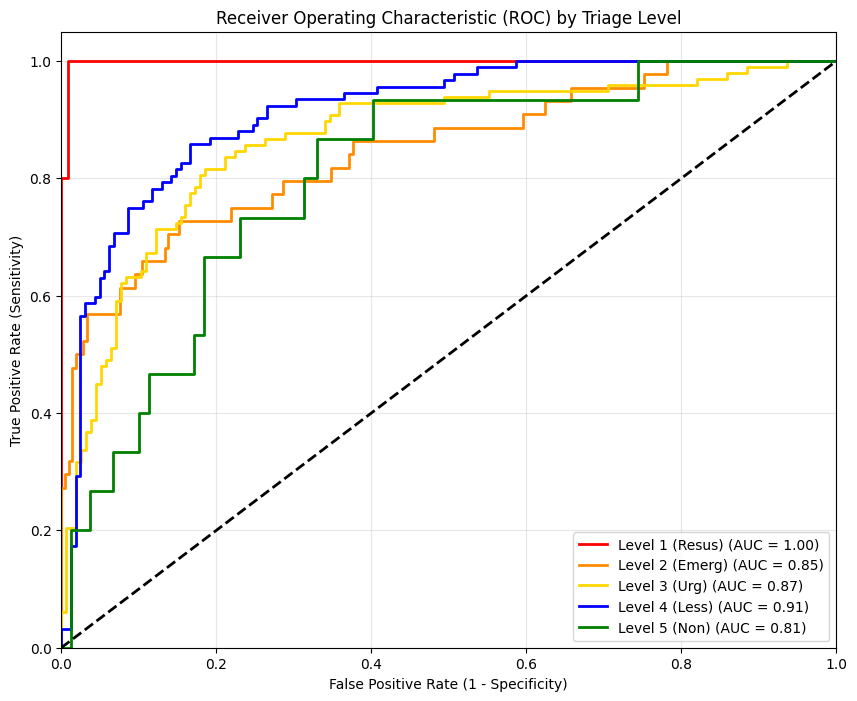

In [177]:
# ---------------------------------------------------------
# INSERT THIS IN SECTION 4.5.5 (After Confusion Matrix)
# ---------------------------------------------------------
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

print("📈 Generating Multi-Class ROC Curves...")

# 1. Binarize the test targets (One-vs-Rest strategy)
# The model predicts 0,1,2,3,4. We need binary flags for each.
y_test_bin = label_binarize(y_test_tuned, classes=[0, 1, 2, 3, 4])
n_classes = y_test_bin.shape[1]

# 2. Get probabilities for each class
y_score = final_xgb.predict_proba(X_test)

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot
plt.figure(figsize=(10, 8))
colors = cycle(['red', 'darkorange', 'gold', 'blue', 'green'])
class_labels = ['Level 1 (Resus)', 'Level 2 (Emerg)', 'Level 3 (Urg)', 'Level 4 (Less)', 'Level 5 (Non)']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='{0} (AUC = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) by Triage Level')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

🎨 Attempting Robust Level 1 Plot...
ℹ️ Format: 3D Array (254, 34, 5)


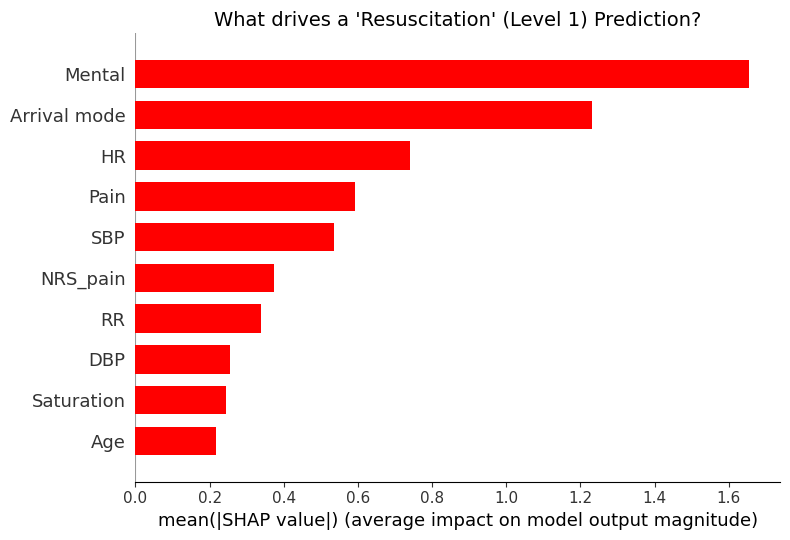

🐝 Generating Detailed Beeswarm for Level 1...


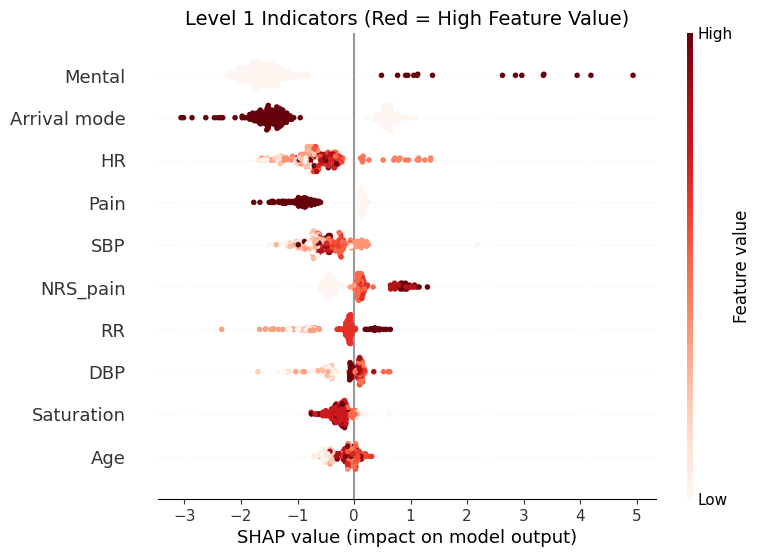

In [178]:
# ---------------------------------------------------------
# Step 8 (Fixed): Robust Level 1 Visualization
# ---------------------------------------------------------
import shap
import matplotlib.pyplot as plt
import numpy as np

print("🎨 Attempting Robust Level 1 Plot...")

# 1. Get Values
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test)

# 2. INTELLIGENT SLICING (The Fix)
# We find the correct matrix for 'Class 0' (Level 1) automatically
target_shap_matrix = None

if isinstance(shap_values, list):
    print(f"ℹ️ Format: List of {len(shap_values)} arrays.")
    target_shap_matrix = shap_values[0] # Class 0 is the first item
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print(f"ℹ️ Format: 3D Array {shap_values.shape}")
    target_shap_matrix = shap_values[:, :, 0] # Class 0 is the 0th index in 3rd dim
else:
    print("⚠️ Unknown SHAP format. Using raw values (might fail).")
    target_shap_matrix = shap_values

# 3. GENERATE THE PLOT (If matrix found)
if target_shap_matrix is not None:
    plt.figure(figsize=(10, 6))
    plt.title("What drives a 'Resuscitation' (Level 1) Prediction?", fontsize=14)
    
    # We use a simple Bar plot first (Safest)
    shap.summary_plot(
        target_shap_matrix, 
        X_test, 
        plot_type="bar",
        max_display=10, 
        color='red', # Force red color for danger
        show=False
    )
    plt.show()
    
    # Try Beeswarm only if Bar worked
    print("🐝 Generating Detailed Beeswarm for Level 1...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        target_shap_matrix, 
        X_test, 
        max_display=10,
        cmap='Reds',
        show=False
    )
    plt.title("Level 1 Indicators (Red = High Feature Value)", fontsize=14)
    plt.show()

<Figure size 1200x800 with 0 Axes>

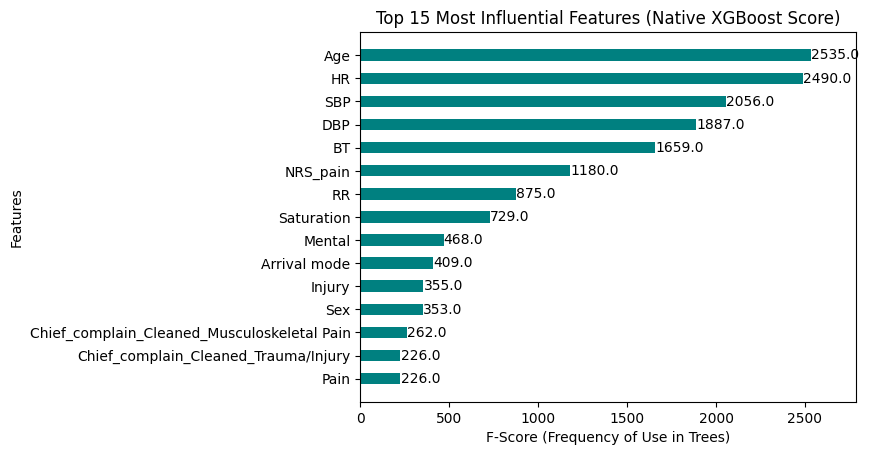

In [179]:
# ---------------------------------------------------------
# Backup: Native XGBoost Feature Importance
# ---------------------------------------------------------
from xgboost import plot_importance

plt.figure(figsize=(12, 8))
# 'gain' = Average gain of splits which use the feature
plot_importance(
    final_xgb, 
    importance_type='weight', 
    max_num_features=15, 
    height=0.5, 
    title='Top 15 Most Influential Features (Native XGBoost Score)',
    xlabel='F-Score (Frequency of Use in Trees)',
    grid=False,
    color='teal'
)
plt.show()

In [180]:
# ---------------------------------------------------------
# INSERT THIS AT THE VERY END OF SECTION 4.5.5
# ---------------------------------------------------------
import joblib

print("💾 Saving Final Deployment Package...")

# We create a dictionary containing EVERYTHING the app needs
deployment_package = {
    'model': final_xgb,                  # The trained XGBoost Brain
    'features': X_train.columns.tolist() # The list of columns (inputs) the model expects
}

# Save as a single pickle file
joblib.dump(deployment_package, 'ktas_deployment_pipeline.pkl')

print("✅ Success! 'ktas_deployment_pipeline.pkl' saved.")
print("   - Includes Model: XGBoost")
print(f"   - Includes Feature Map: {len(X_train.columns)} columns")

💾 Saving Final Deployment Package...
✅ Success! 'ktas_deployment_pipeline.pkl' saved.
   - Includes Model: XGBoost
   - Includes Feature Map: 34 columns
